In [ ]:
"""Plot damped-system position and velocity on dual y-axes."""

import matplotlib.pyplot as plt
import numpy as np


# Styling
base_fontsize = 18
linewidth = 1.5

niceblue = "#4d7da7"
nicered = "#e15656"
nicegray = "#6e6e6e"

plt.rcParams["figure.dpi"] = 600
plt.rcParams["savefig.dpi"] = 600
plt.rcParams["mathtext.fontset"] = "cm"
plt.rcParams["font.family"] = "serif"

plt.rcParams["lines.linewidth"] = linewidth
plt.rcParams["axes.labelsize"] = base_fontsize
plt.rcParams["axes.titlesize"] = base_fontsize
plt.rcParams["xtick.labelsize"] = base_fontsize - 3
plt.rcParams["ytick.labelsize"] = base_fontsize - 3

plt.rcParams["legend.fontsize"] = base_fontsize - 4
plt.rcParams["legend.frameon"] = True
plt.rcParams["legend.facecolor"] = "white"
plt.rcParams["legend.edgecolor"] = "#e0e0e0"
plt.rcParams["legend.loc"] = "upper right"


# Data
t = np.linspace(0, 10, 500)
damping_factor = 0.4

y_position = np.exp(-damping_factor * t) * np.cos(2 * np.pi * 0.5 * t)

y_velocity = (
    -damping_factor * np.exp(-damping_factor * t) * np.cos(2 * np.pi * 0.5 * t)
    - 2
    * np.pi
    * 0.5
    * np.exp(-damping_factor * t)
    * np.sin(2 * np.pi * 0.5 * t)
)


# Plot
fig, ax1 = plt.subplots(figsize=(10, 6))

(line1,) = ax1.plot(
    t,
    y_position,
    color=niceblue,
    label=r"Position $x(t)$",
    linewidth=2,
)

ax1.set_xlabel("Time, $t$ (s)")
ax1.set_ylabel("Displacement, $x$ (m)", color=niceblue)
ax1.tick_params(axis="y", labelcolor=niceblue)

ax2 = ax1.twinx()

(line2,) = ax2.plot(
    t,
    y_velocity,
    color=nicered,
    label=r"Velocity $v(t)$",
    linewidth=2,
)

ax2.set_ylabel("Velocity, $v$ (m/s)", color=nicered)
ax2.tick_params(axis="y", labelcolor=nicered)

ax1.grid(False)
ax2.grid(False)

lines = [line1, line2]
labels = [line.get_label() for line in lines]
ax1.legend(lines, labels)

plt.title("System Dynamics Over Time")
plt.tight_layout()
# plt.savefig("single_plot_dual_axis.png", bbox_inches="tight")
plt.show()

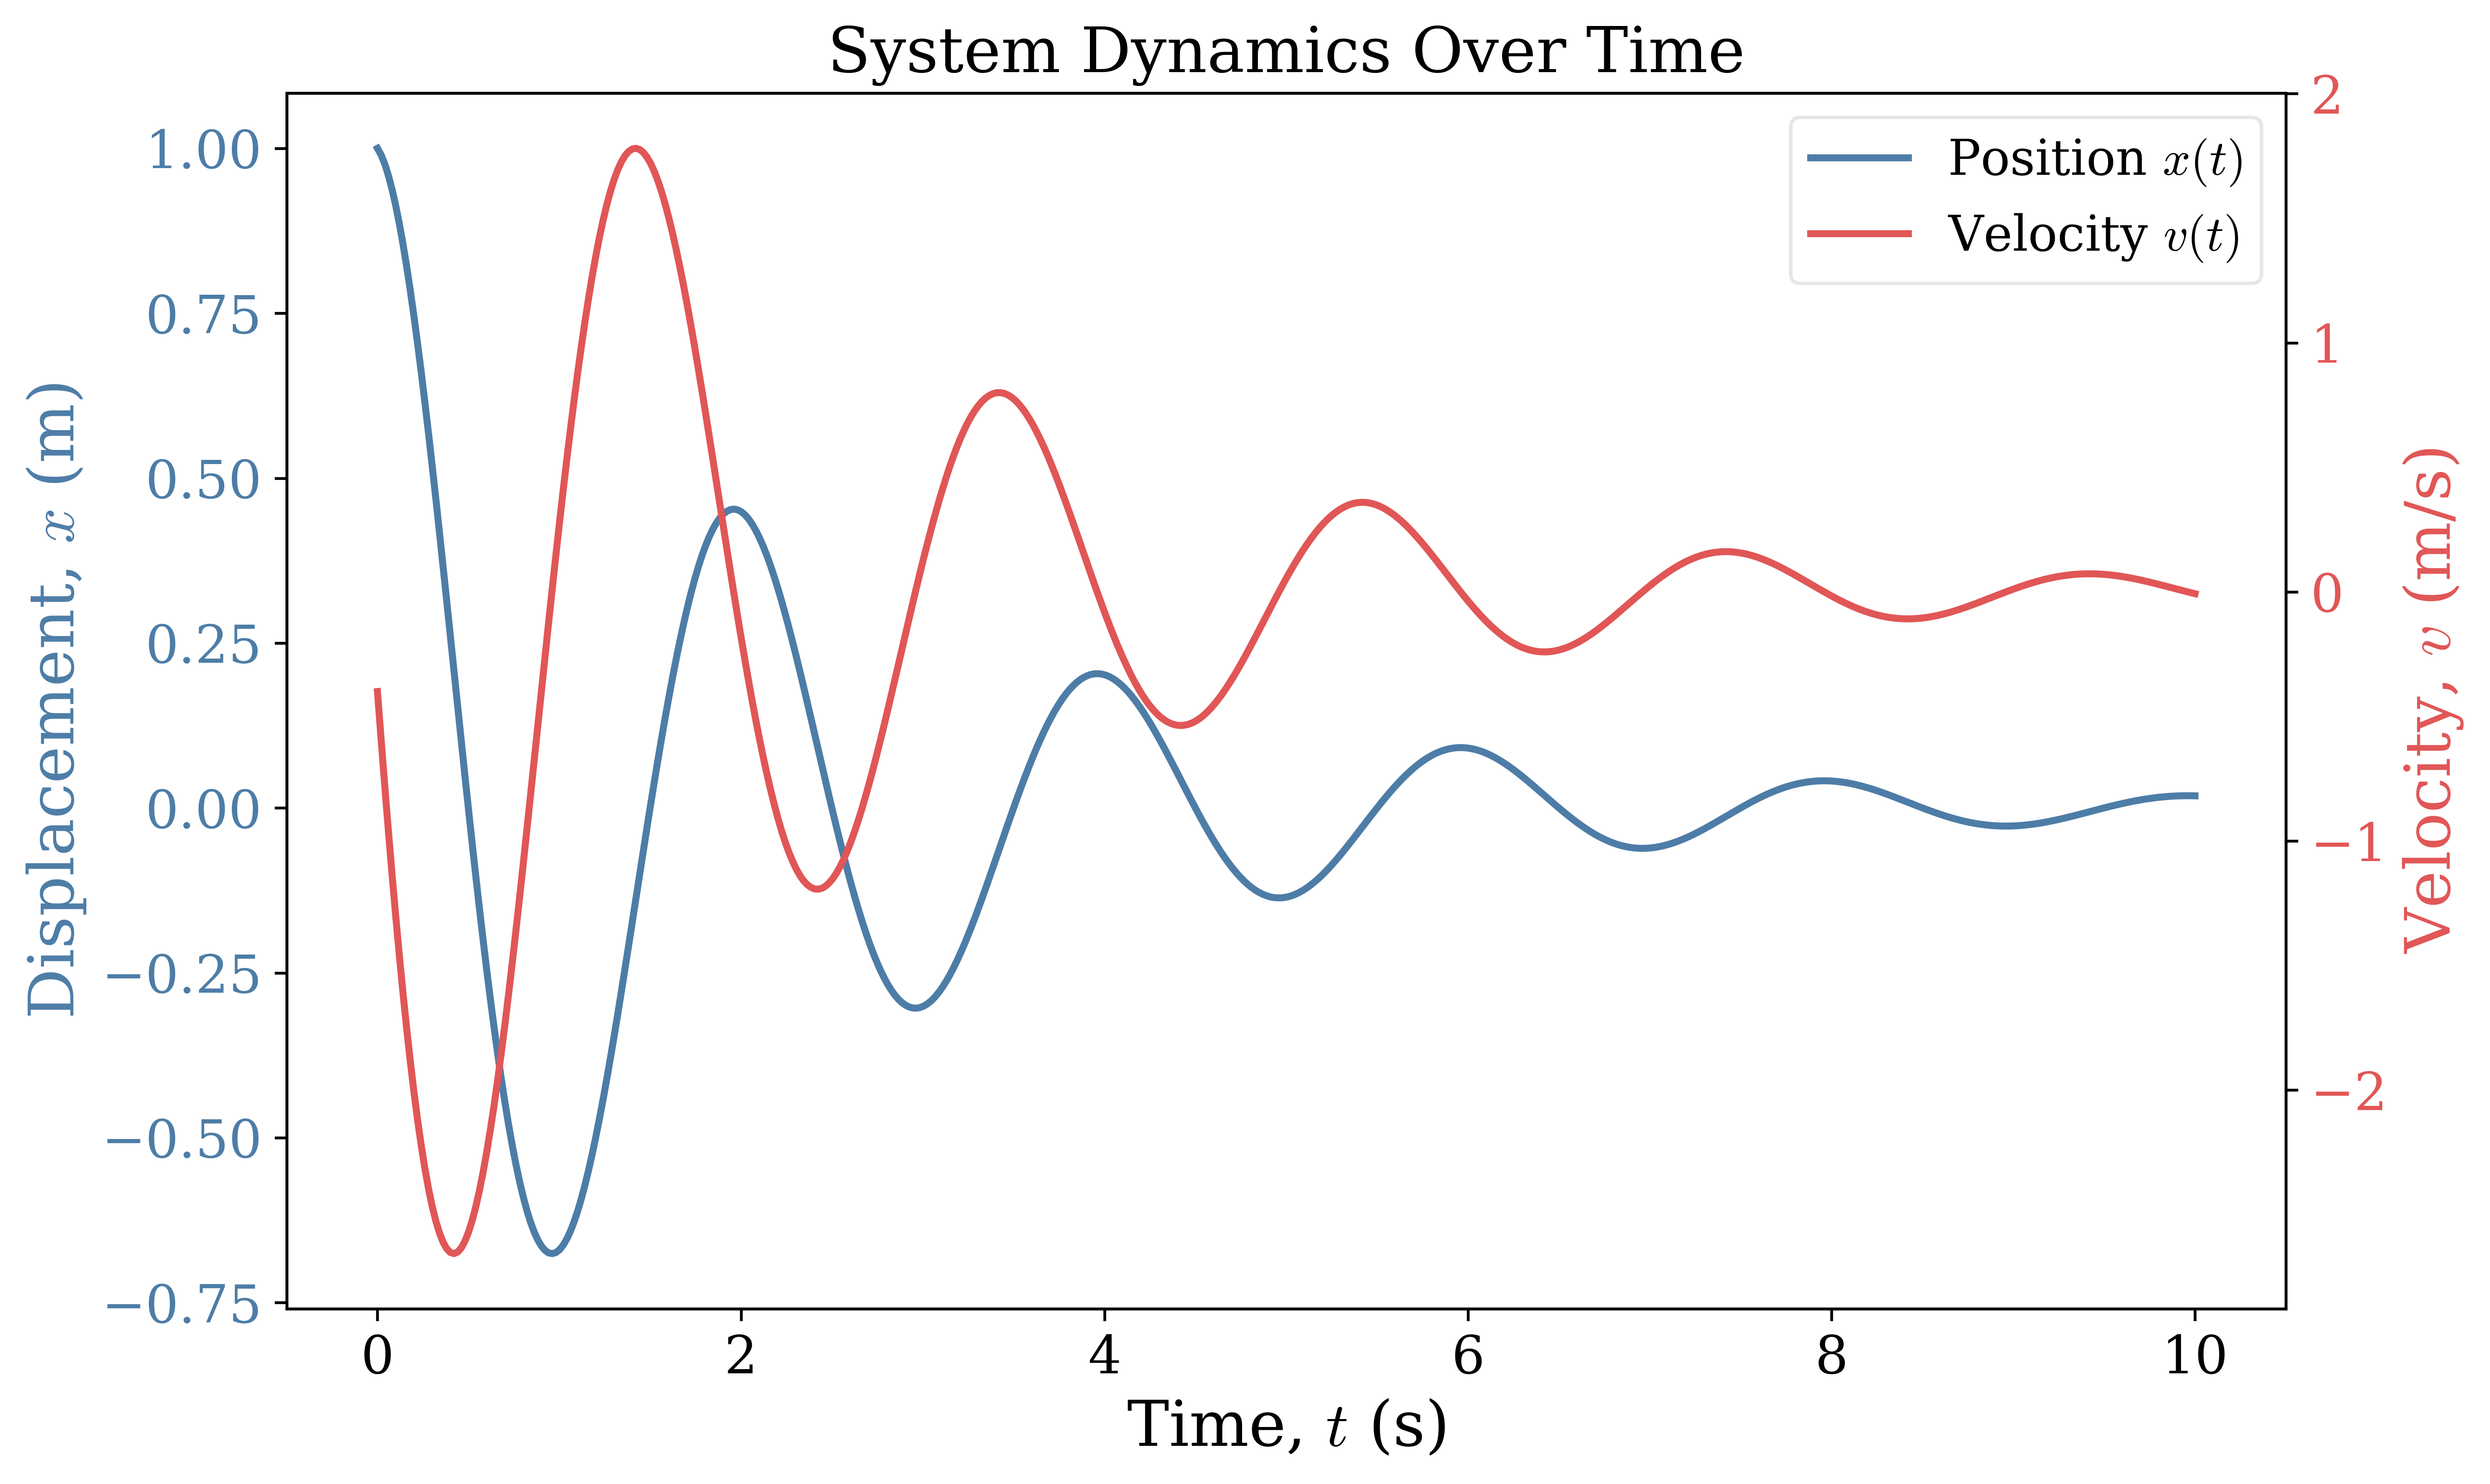

In [3]:
import matplotlib.pyplot as plt
import numpy as np


BASE_FONTSIZE = 18
LINEWIDTH = 1.5

NICE_BLUE = "#4d7da7"
NICE_RED = "#e15656"

DAMPING_FACTOR = 0.4
FREQUENCY = 0.5
OUTPUT_PATH = "single_plot_dual_axis.png"


def configure_plot_style(base_fontsize: int, linewidth: float) -> None:
    """Configure global Matplotlib styling for publication-quality plots."""
    plt.rcParams.update(
        {
            "figure.dpi": 600,
            "savefig.dpi": 600,
            "mathtext.fontset": "cm",
            "font.family": "serif",
            "lines.linewidth": linewidth,
            "axes.labelsize": base_fontsize,
            "axes.titlesize": base_fontsize,
            "xtick.labelsize": base_fontsize - 3,
            "ytick.labelsize": base_fontsize - 3,
            "legend.fontsize": base_fontsize - 4,
            "legend.frameon": True,
            "legend.facecolor": "white",
            "legend.edgecolor": "#e0e0e0",
            "legend.loc": "upper right",
        }
    )


def calculate_damped_motion(
    time: np.ndarray,
    damping_factor: float,
    frequency: float,
) -> tuple[np.ndarray, np.ndarray]:
    """Calculate position and velocity for a damped oscillating system."""
    angular_frequency = 2 * np.pi * frequency
    exponential_decay = np.exp(-damping_factor * time)

    position = exponential_decay * np.cos(angular_frequency * time)

    velocity = (
        -damping_factor * exponential_decay * np.cos(angular_frequency * time)
        - angular_frequency * exponential_decay * np.sin(angular_frequency * time)
    )

    return position, velocity


def create_dual_axis_plot(
    time: np.ndarray,
    position: np.ndarray,
    velocity: np.ndarray,
    output_path: str,
) -> None:
    """Create, save, and display a dual y-axis system dynamics plot."""
    fig, position_axis = plt.subplots(figsize=(10, 6))

    (position_line,) = position_axis.plot(
        time,
        position,
        color=NICE_BLUE,
        linewidth=2,
        label=r"Position $x(t)$",
    )

    position_axis.set_xlabel("Time, $t$ (s)")
    position_axis.set_ylabel("Displacement, $x$ (m)", color=NICE_BLUE)
    position_axis.tick_params(axis="y", labelcolor=NICE_BLUE)
    position_axis.grid(False)

    velocity_axis = position_axis.twinx()

    (velocity_line,) = velocity_axis.plot(
        time,
        velocity,
        color=NICE_RED,
        linewidth=2,
        label=r"Velocity $v(t)$",
    )

    velocity_axis.set_ylabel("Velocity, $v$ (m/s)", color=NICE_RED)
    velocity_axis.tick_params(axis="y", labelcolor=NICE_RED)
    velocity_axis.grid(False)

    position_axis.legend(
        [position_line, velocity_line],
        [position_line.get_label(), velocity_line.get_label()],
    )

    position_axis.set_title("System Dynamics Over Time")

    fig.tight_layout()
    # fig.savefig(output_path, bbox_inches="tight")
    plt.show()


def main() -> None:
    """Generate damped-system data and visualize position and velocity."""
    configure_plot_style(BASE_FONTSIZE, LINEWIDTH)

    time = np.linspace(0, 10, 500)

    position, velocity = calculate_damped_motion(
        time=time,
        damping_factor=DAMPING_FACTOR,
        frequency=FREQUENCY,
    )

    create_dual_axis_plot(
        time=time,
        position=position,
        velocity=velocity,
        output_path=OUTPUT_PATH,
    )


if __name__ == "__main__":
    main()

In [ ]:
"""Plot GPU-generated damped-system position and velocity on dual y-axes."""

!pip install cupy-cuda12x --quiet

import matplotlib.pyplot as plt
import cupy as cp


# Styling
base_fontsize = 18
linewidth = 1.5

niceblue = "#4d7da7"
nicered = "#e15656"

plt.rcParams["figure.dpi"] = 600
plt.rcParams["savefig.dpi"] = 600
plt.rcParams["mathtext.fontset"] = "cm"
plt.rcParams["font.family"] = "serif"

plt.rcParams["lines.linewidth"] = linewidth
plt.rcParams["axes.labelsize"] = base_fontsize
plt.rcParams["axes.titlesize"] = base_fontsize
plt.rcParams["xtick.labelsize"] = base_fontsize - 3
plt.rcParams["ytick.labelsize"] = base_fontsize - 3
plt.rcParams["legend.fontsize"] = base_fontsize - 4


# GPU data
t = cp.linspace(0, 10, 500)
damping_factor = 0.4

y_position = cp.exp(-damping_factor * t) * cp.cos(2 * cp.pi * 0.5 * t)

y_velocity = (
    -damping_factor * cp.exp(-damping_factor * t) * cp.cos(2 * cp.pi * 0.5 * t)
    - 2
    * cp.pi
    * 0.5
    * cp.exp(-damping_factor * t)
    * cp.sin(2 * cp.pi * 0.5 * t)
)

t_cpu = t.get()
y_position_cpu = y_position.get()
y_velocity_cpu = y_velocity.get()


# Plot
fig, ax1 = plt.subplots(figsize=(10, 6))

(line1,) = ax1.plot(
    t_cpu,
    y_position_cpu,
    color=niceblue,
    label=r"Position $x(t)$",
    linewidth=2,
)

ax1.set_xlabel("Time, $t$ (s)")
ax1.set_ylabel("Displacement, $x$ (m)", color=niceblue)
ax1.tick_params(axis="y", labelcolor=niceblue)

ax2 = ax1.twinx()

(line2,) = ax2.plot(
    t_cpu,
    y_velocity_cpu,
    color=nicered,
    label=r"Velocity $v(t)$",
    linewidth=2,
)

ax2.set_ylabel("Velocity, $v$ (m/s)", color=nicered)
ax2.tick_params(axis="y", labelcolor=nicered)

lines = [line1, line2]
labels = [line.get_label() for line in lines]

ax1.legend(
    lines,
    labels,
    loc="upper right",
    frameon=True,
    facecolor="white",
    edgecolor="none",
)

plt.title("System Dynamics Over Time")
plt.tight_layout()
plt.savefig("single_plot_dual_axis.png", bbox_inches="tight")
plt.show()